In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Set your file path here ----
DATA_PATH = Path("data/processed/sp500_panel.csv")  # Update path if needed

# Runtime settings
SAMPLE_ROWS = 200_000
CHUNKSIZE = 200_000
TARGET_COL = "y_return"

print("Using file:", DATA_PATH)

Using file: data/processed/sp500_panel.csv


In [2]:
#no missing value confirmation
df = pd.read_csv(DATA_PATH)
n_rows = len(df)

missing_count = df.isna().sum()
missing_pct = (missing_count / n_rows * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

display(missing_table.head(20))

,missing_count,missing_pct
Date,0,0.0
Close,0,0.0
High,0,0.0
Low,0,0.0
Open,0,0.0
Volume,0,0.0
Ticker,0,0.0
y_return,0,0.0
y_direction,0,0.0
Returnlag,0,0.0


In [3]:
#no duplicate confirmation
print("Duplicate full rows:", df.duplicated().sum())

date_col = "Date" if "Date" in df.columns else None
ticker_col = "Ticker" if "Ticker" in df.columns else None

if date_col and ticker_col:
    key_duplicates = df.duplicated(subset=[ticker_col, date_col]).sum()
    print(f"Duplicate ({ticker_col}, {date_col}) keys:", key_duplicates)

Duplicate full rows: 0
Duplicate (Ticker, Date) keys: 0


In [4]:
# structure anlaysis
if ticker_col:
    print("Unique tickers:", df[ticker_col].nunique())

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    print("Date range:", df[date_col].min(), "to", df[date_col].max())

if ticker_col:
    display(df.groupby(ticker_col).size().describe())

Unique tickers: 501
Date range: 2015-12-28 00:00:00 to 2025-12-18 00:00:00


count     501.000000
mean     2431.576846
std       336.325100
min        34.000000
25%      2510.000000
50%      2510.000000
75%      2510.000000
max      2510.000000
dtype: float64

In [5]:
# checking skewness of the data
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

skew_series = df[numeric_cols].apply(
    lambda s: pd.to_numeric(s, errors='coerce').dropna().skew()
)

skew_table = skew_series.to_frame("skewness").sort_values("skewness", ascending=False)

def skew_label(v):
    if pd.isna(v): return "NA"
    if v > 1: return "Highly right-skewed"
    if v > 0.5: return "Moderately right-skewed"
    if v < -1: return "Highly left-skewed"
    if v < -0.5: return "Moderately left-skewed"
    return "Approximately symmetric"

skew_table["interpretation"] = skew_table["skewness"].apply(skew_label)

display(skew_table)

,skewness,interpretation
Volume,24.736733,Highly right-skewed
Low,14.868403,Highly right-skewed
MA_5,14.854312,Highly right-skewed
Open,14.853505,Highly right-skewed
Close,14.848949,Highly right-skewed
High,14.843934,Highly right-skewed
HL_range,4.466588,Highly right-skewed
Volatility_5,3.808282,Highly right-skewed
OC_change,0.257815,Approximately symmetric
Returnlag,0.082394,Approximately symmetric


In [6]:
#outlier detection
outlier_rows = []

for c in numeric_cols:
    s = pd.to_numeric(df[c], errors='coerce').dropna()
    if len(s) < 5:
        continue
        
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    out_count = ((s < lo) | (s > hi)).sum()
    out_pct = 100 * out_count / len(s)
    
    outlier_rows.append([c, int(out_count), round(out_pct,2), lo, hi])

outlier_df = pd.DataFrame(
    outlier_rows,
    columns=["feature", "outlier_count", "outlier_pct", "lower_bound", "upper_bound"]
).sort_values("outlier_pct", ascending=False)

display(outlier_df)

,feature,outlier_count,outlier_pct,lower_bound,upper_bound
4,Volume,126930,10.42,-5.037100e+06,1.113570e+07
1,High,92579,7.60,-1.155350e+02,3.052309e+02
0,Close,92403,7.59,-1.142816e+02,3.018491e+02
3,Open,92400,7.58,-1.142240e+02,3.017475e+02
12,MA_5,92384,7.58,-1.140977e+02,3.014828e+02
2,Low,92149,7.56,-1.129883e+02,2.983622e+02
8,log_return,77320,6.35,-3.563898e-02,3.711754e-02
5,y_return,77098,6.33,-3.563141e-02,3.719716e-02
7,Returnlag,77143,6.33,-3.562472e-02,3.718660e-02
9,HL_range,69754,5.73,-7.518392e-03,4.983481e-02


In [7]:
#correlation analysis (chunked so memory safe)

preview = pd.read_csv(DATA_PATH, nrows=5000)
preview.columns = preview.columns.str.strip().str.replace(" ", "_", regex=False)

candidate_numeric = preview.select_dtypes(include=[np.int64, np.float64]).columns.tolist()

corr_sample_df = pd.DataFrame(columns=candidate_numeric)
max_sample_rows = 200_000
rows_seen = 0
rng = np.random.default_rng(42)

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNKSIZE, usecols=candidate_numeric):
    
    chunk.columns = chunk.columns.str.strip().str.replace(" ", "_", regex=False)
    chunk = chunk.dropna(how="all")
    
    chunk_n = len(chunk)
    rows_seen += chunk_n
    
    space_left = max_sample_rows - len(corr_sample_df)
    
    if space_left > 0:
        take_n = min(space_left, chunk_n)
        corr_sample_df = pd.concat(
            [corr_sample_df, chunk.iloc[:take_n]],
            ignore_index=True
        )
        chunk = chunk.iloc[take_n:]
    
    if not chunk.empty and len(corr_sample_df) > 0:
        p = max_sample_rows / rows_seen
        keep_mask = rng.random(len(chunk)) < p
        candidates = chunk.loc[keep_mask]
        
        if not candidates.empty:
            replace_idx = rng.integers(0, len(corr_sample_df), size=len(candidates))
            corr_sample_df.iloc[replace_idx] = candidates.values

print("Rows scanned:", rows_seen)
print("Rows kept:", len(corr_sample_df))

corr = corr_sample_df.corr()
display(corr.round(3))


Rows scanned: 1218220
Rows kept: 200000


,Close,High,Low,Open,Volume,y_return,y_direction,Returnlag,log_return,HL_range,OC_change,Volume_log,MA_5,Volatility_5
Close,1.000,1.000,1.000,1.000,-0.059,-0.006,-0.001,0.005,0.005,-0.014,0.004,-0.287,1.000,-0.017
High,1.000,1.000,1.000,1.000,-0.058,-0.006,-0.001,0.002,0.002,-0.010,-0.000,-0.286,1.000,-0.015
Low,1.000,1.000,1.000,1.000,-0.059,-0.006,-0.001,0.002,0.003,-0.016,0.000,-0.287,1.000,-0.019
Open,1.000,1.000,1.000,1.000,-0.059,-0.006,-0.001,-0.001,-0.000,-0.013,-0.004,-0.287,1.000,-0.017
Volume,-0.059,-0.058,-0.059,-0.059,1.000,0.004,-0.001,0.003,-0.002,0.140,0.004,0.422,-0.059,0.141
y_return,-0.006,-0.006,-0.006,-0.006,0.004,1.000,0.644,-0.040,-0.042,0.033,-0.030,0.003,-0.006,0.037
y_direction,-0.001,-0.001,-0.001,-0.001,-0.001,0.644,1.000,-0.020,-0.020,-0.003,-0.015,0.010,-0.001,-0.012
Returnlag,0.005,0.002,0.002,-0.001,0.003,-0.040,-0.020,1.000,0.998,-0.082,0.814,-0.003,-0.002,-0.014
log_return,0.005,0.002,0.003,-0.000,-0.002,-0.042,-0.020,0.998,1.000,-0.113,0.811,-0.009,-0.001,-0.040
HL_range,-0.014,-0.010,-0.016,-0.013,0.140,0.033,-0.003,-0.082,-0.113,1.000,-0.058,0.239,-0.012,0.678


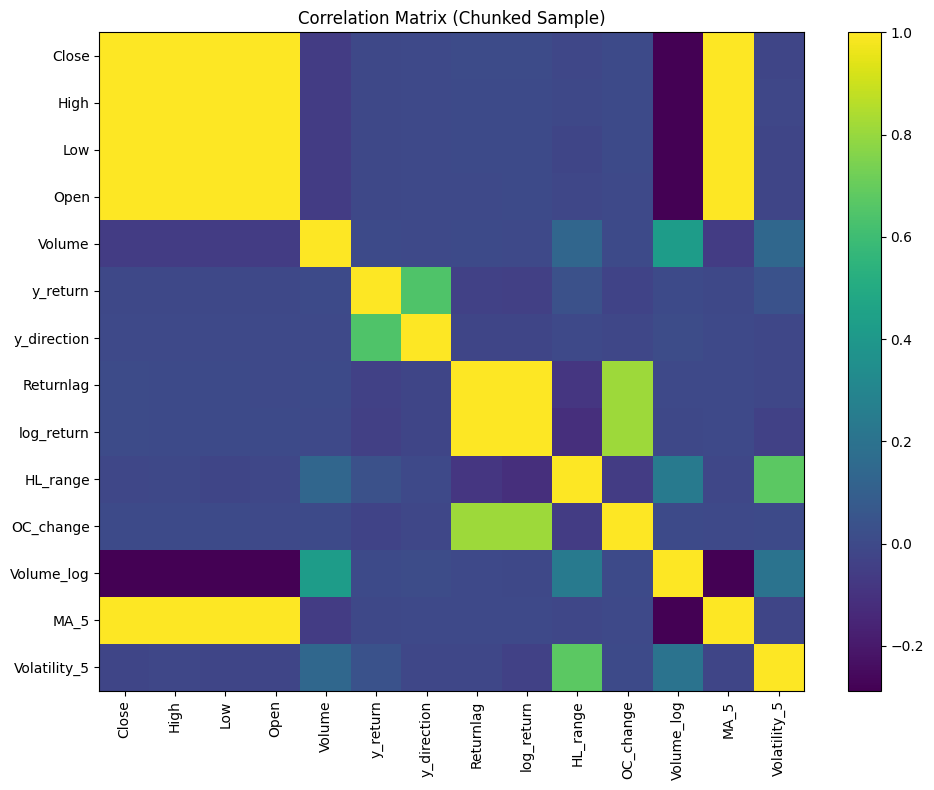

In [8]:
#heatmap

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (Chunked Sample)")
plt.tight_layout()
plt.show()


Overall Observations for part 1:

1. Basic Info about data -:

total data entries : 1218220

columns: 16

data types: float64(12), int64(2), object(2)

2. Important data analysis values:

count 501.000000

mean 2431.576846

std 336.325100

min 34.000000

25% 2510.000000

50% 2510.000000

75% 2510.000000

max 2510.000000

// Also a quick check to make sure null values were removed during pre-processing.

3. Graphical Distributions:

Normal closing graph did not help much, also made a log graph, appears as a gaussian curve.

4. Top 10 countries:

Nvidia, Tesla, Apple, Netflix, Amazon, AMD, BAC, PLTR, F, T

5. Avg & Individual stocks

 Average stock trends for all companies an few individual companies.

 a. Nvidia had a flat growth in the initial years and started picking up in 2023.

 b. Tesla stocks started slowly piking in 2019 but keep rigourously fluctuating between pikes and lows.

 c. Other stocks like Apple, Microsoft, Google and Amazon all started picking up in 2019 and are still rising with microsoft having the hightest peak in 2025.

 d. General observation is that except Nvidia, every other company started peaking in 2019 but NVidia was abit later in 2021.  

The EDA shows that the dataset is generally suitable for modeling, with clear structure across core price/volume features. Several numeric variables are visibly right-skewed and contain extreme values, indicating that robust preprocessing (such as scaling, winsorization, and log transforms) is important before training. Correlation patterns suggest meaningful relationships among market variables while preserving sufficient distinct information for multi-feature models. The outlier analysis also confirms that volatility-heavy periods are present, which is consistent with the project’s regime-based framing. These results support using market-regime signals together with stock-level engineered features rather than relying on stock-only inputs. Overall, the EDA findings provide a solid foundation for moving into model training, hyperparameter tuning, and comparative evaluation across baseline and regime-aware approaches.